In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.membrane_node import MembraneNode
from abm.flow_field import FlowField
from abm.spring import Spring
from abm.stress_fibre import StressFibre
from abm.endothelial_cell import EndothelialCell
from abm.rho_lookup_table import RhoLookupTable
from src.config import load_abm_sim_cfg
from src.paths import BM_RESULTS_DIR

CFG = load_abm_sim_cfg()
lut = RhoLookupTable(CFG, BM_RESULTS_DIR)
flow = FlowField()
from abm.signalling import get_protein_recruitment
from abm.scripts.run_abm_sim import run_abm_sim_single, run_abm_sim


def plot_cell(cell, ax=None, show_ids=True):
    """
    Very basic visualisation of the cell.

    Shows:
        - membrane nodes (with optional IDs)
        - centroid
        - cortical springs
        - stress fibres
        - FA anchor points
    """
    if ax is None:
        fig, ax = plt.subplots()

    # -------------------------
    # Nodes
    # -------------------------
    xs = [n.pos[0] for n in cell.nodes]
    ys = [n.pos[1] for n in cell.nodes]

    ax.scatter(xs, ys)

    # Label node IDs
    if show_ids:
        for n in cell.nodes:
            ax.text(n.pos[0], n.pos[1], str(n.id), fontsize=8)

    # -------------------------
    # Springs (membrane edges)
    # -------------------------
    for s in cell.springs:
        x = [s.node_1.pos[0], s.node_2.pos[0]]
        y = [s.node_1.pos[1], s.node_2.pos[1]]
        ax.plot(x, y)

    # -------------------------
    # Stress fibres
    # -------------------------
    for sf in cell.stress_fibres:
        x = [sf.node_upstream.pos[0], sf.node_downstream.pos[0]]
        y = [sf.node_upstream.pos[1], sf.node_downstream.pos[1]]
        ax.plot(x, y, linestyle='--')

    # -------------------------
    # FA anchors (fixed points)
    # -------------------------
    for node_id, pos in cell.fa_nodes.items():
        ax.scatter(pos[0], pos[1], marker='x')

    # -------------------------
    # Centroid
    # -------------------------
    centroid = cell.centroid
    ax.scatter(centroid[0], centroid[1], marker='o')

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_aspect('equal')
    ax.set_title(f"Cell {cell.id}")

    plt.show()
    plt.close()


import pandas as pd
import numpy as np

def build_diagnostics(history):
    sf_fa_rows = []
    squeeze_rows = []

    for step, diag in enumerate(history):

        # -------------------------
        # Stress fibre (assume 1 for now)
        # -------------------------
        sf = diag["stress_fibres"][0]

        sf_force = sf["force_vector"]

        # -------------------------
        # Focal adhesions
        # -------------------------
        for node_id, fa in diag["fa"].items():

            sf_fa_rows.append({
                "step": step,

                # SF
                "sf_tension": sf["tension"],
                "sf_length": sf["length"],
                "sf_force_x": round(sf_force[0], 3),
                "sf_force_y": round(sf_force[1], 3),

                # FA
                "fa_id": node_id,
                "fa_force_x": fa["force"][0],
                "fa_force_y": fa["force"][1],
                "fa_force_mag": fa["force_mag"],
            })

        # -------------------------
        # Squeeze (per node)
        # -------------------------
        squeeze_profile = diag["squeeze_profiles"][0]

        for node_id, f in squeeze_profile.items():
            squeeze_rows.append({
                "step": step,
                "node_id": node_id,
                "squeeze_force_y": f
            })

    df_sf_fa = pd.DataFrame(sf_fa_rows)
    df_squeeze = pd.DataFrame(squeeze_rows)

    return df_sf_fa, df_squeeze

>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.463 RhoC=0.437


In [2]:
def run_sim_test(cell, n_steps):
    plot_cell(cell)

    history = []
    sf_profiles = {}

    for step in range(n_steps):
        cell.step(flow, dt=CFG['integration']['dt'])

        diag = cell.get_diagnostics()
        history.append(diag)
        sf_profiles[step] = diag['squeeze_profiles']
        
        if step % 50 == 0:
            s = cell.get_state()
            print(f"step {step:>4}: ar={s['ar']:.3f}  "
                f"orient={s['orientation']:.1f}°  "
                f"a_sf={s['a_sf']:.4f}  "
                f"RhoA={s['mean_rhoa']:.3f}  "
                f"RhoC={s['mean_rhoc']:.3f}  "
                f"area={s['area_err']:.3f}")
            
            # sf = diag["stress_fibres"][0]

            # print(f"Step {step}")
            # print("  SF tension:", sf["tension"])
            # print("  SF direction:", sf["unit_vec"])
            # print("  SF force:", sf["force_vector"])

            # for nid, fa in diag["fa"].items():
            #     print(f"  FA {nid} force:", fa["force"])

    s = cell.get_state()
    plot_cell(cell)
    print(f"\nFinal: {cell}")

    return history, sf_profiles


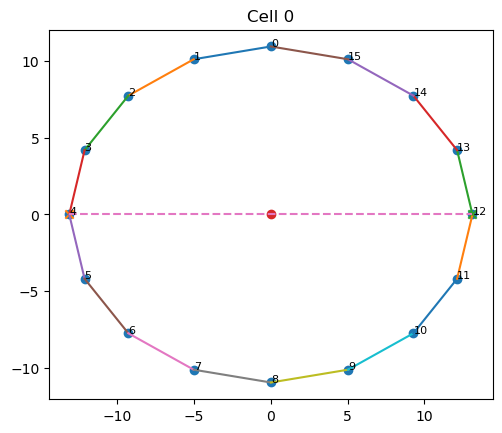

step    0: ar=1.203  orient=0.0°  a_sf=0.0015  RhoA=0.564  RhoC=0.591  area=1.003
step   50: ar=1.345  orient=0.0°  a_sf=0.0710  RhoA=0.564  RhoC=0.591  area=1.074
step  100: ar=1.472  orient=0.0°  a_sf=0.1298  RhoA=0.564  RhoC=0.591  area=1.070
step  150: ar=1.572  orient=0.0°  a_sf=0.1801  RhoA=0.551  RhoC=0.594  area=1.042
step  200: ar=1.649  orient=0.0°  a_sf=0.2225  RhoA=0.550  RhoC=0.591  area=1.008
step  250: ar=1.528  orient=-180.0°  a_sf=0.2581  RhoA=0.511  RhoC=0.589  area=0.997
step  300: ar=1.595  orient=-180.0°  a_sf=0.2879  RhoA=0.511  RhoC=0.589  area=1.010
step  350: ar=1.710  orient=-180.0°  a_sf=0.3125  RhoA=0.511  RhoC=0.589  area=1.000
step  400: ar=1.755  orient=-180.0°  a_sf=0.3334  RhoA=0.511  RhoC=0.589  area=1.000
step  450: ar=1.764  orient=-180.0°  a_sf=0.3490  RhoA=0.529  RhoC=0.594  area=1.000
step  500: ar=1.763  orient=-180.0°  a_sf=0.3662  RhoA=0.529  RhoC=0.594  area=0.999
step  550: ar=1.747  orient=-180.0°  a_sf=0.3807  RhoA=0.529  RhoC=0.594  area=1

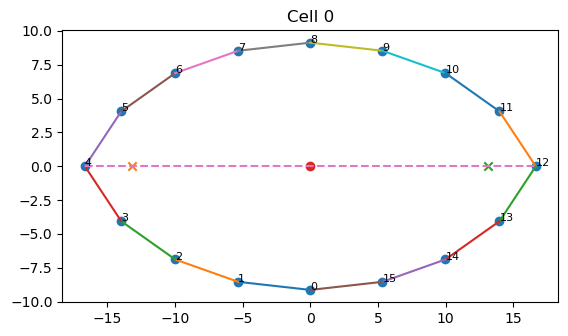


Final: EndothelialCell(id=0 | ar=1.61 | area_err=1.001 | a_sf=0.452 | RhoA=0.550 RhoC=0.591)


In [3]:

flow = FlowField(magnitude=CFG['flow']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['cell_geometry']['n_nodes'],
                       radius=CFG['cell_geometry']['radius'])
history, sf_profiles = run_sim_test(cell, 5000)

In [4]:
df_sf_fa, df_squeeze = build_diagnostics(history)
df_sf_fa

,step,sf_tension,sf_length,sf_force_x,sf_force_y,fa_id,fa_force_x,fa_force_y,fa_force_mag
0,0,0.000000,26.290683,0.000,-0.0,4,0.100000,0.0,0.100000
1,0,0.000000,26.290683,0.000,-0.0,12,-0.100000,-0.0,0.100000
2,1,0.000604,26.390683,0.001,-0.0,4,0.103345,0.0,0.103345
3,1,0.000604,26.390683,0.001,-0.0,12,-0.103345,-0.0,0.103345
4,2,0.001207,26.494028,0.001,-0.0,4,0.103329,0.0,0.103329
...,...,...,...,...,...,...,...,...,...
9995,4997,0.174461,47.690747,0.174,-0.0,12,0.176368,0.0,0.176368
9996,4998,0.174460,47.684990,0.174,-0.0,4,-0.091450,-0.0,0.091450
9997,4998,0.174460,47.684990,0.174,-0.0,12,0.091450,0.0,0.091450
9998,4999,0.174460,47.769907,0.174,-0.0,4,-0.104883,-0.0,0.104883


In [18]:
df_squeeze

,step,node_id,squeeze_force_y
0,0,0,-0.0004
1,0,1,-0.0004
2,0,2,-0.0003
3,0,3,-0.0002
4,0,4,-0.0000
...,...,...,...
7995,499,11,-0.0570
7996,499,12,-0.0000
7997,499,13,0.0570
7998,499,14,0.0793


# Component Tests

### Node Test

In [5]:
# Pole node — high f_normal
n_pole = MembraneNode(0, np.array([12.0, 0.0]), lut, CFG)
n_pole.f_normal = CFG['flow']['f_magnitude']
n_pole.update_signalling()
print(f"Pole node:  f_normal={n_pole.f_normal:.3f} "
      f"P_RhoA={n_pole.P_RhoA:.3f} P_RhoC={n_pole.P_RhoC:.3f}")

# Flank node — zero f_normal
n_flank = MembraneNode(1, np.array([0.0, 12.0]), lut, CFG)
n_flank.f_normal = 0.0
n_flank.update_signalling()
print(f"Flank node: f_normal={n_flank.f_normal:.3f} "
      f"P_RhoA={n_flank.P_RhoA:.3f} P_RhoC={n_flank.P_RhoC:.3f}")

# Pole should have higher RhoA than flank
assert n_pole.P_RhoA > n_flank.P_RhoA, "Pole should have higher RhoA"
#assert n_pole.P_RhoC < n_flank.P_RhoC, "Flank should have higher RhoC"
print("MembraneNode signalling: PASS")

Pole node:  f_normal=15.000 P_RhoA=0.722 P_RhoC=0.300
Flank node: f_normal=0.000 P_RhoA=0.463 P_RhoC=0.437
MembraneNode signalling: PASS


### Spring Test

In [8]:
flow = np.array([1.0, 0.0])

n1 = MembraneNode(0, np.array([0.0, 0.0]), lut, CFG)
n2 = MembraneNode(1, np.array([5.0, 0.0]), lut, CFG)
s  = Spring(0, n1, n2, rest_length=5.0,
            k_cortex=CFG['mechanics']['k_cortex'],
            lut=lut, cfg=CFG)
s._init_alignment = 1.0

# Test 1 — at rest, no RhoA
s.update_geometry(flow)
s.update_cortex()
print(f"At rest:    T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert abs(s.t_cortex) < 1e-6

# Test 2 — stretched, no RhoA
n2.pos = np.array([7.0, 0.0])
s.update_geometry(flow)
s.update_cortex()
print(f"Stretched:  T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert s.t_cortex > 0

# Test 3 — stretched, high RhoA at both nodes
n1.P_RhoA = 0.7
n2.P_RhoA = 0.7
s.update_geometry(flow)
s.update_cortex()
print(f"High RhoA:  T={s.t_cortex:.4f}  k={s.k_active:.4f}")
assert s.k_active > CFG['mechanics']['k_cortex']

# Test 4 — asymmetric RhoA
n1.P_RhoA = 0.7
n2.P_RhoA = lut.rhoa_rest
s.update_geometry(flow)
s.update_cortex()
k_asym = s.k_active
n1.P_RhoA = 0.7
n2.P_RhoA = 0.7
s.update_geometry(flow)
s.update_cortex()
k_high = s.k_active
print(f"Asymmetric k={k_asym:.4f}  both-high k={k_high:.4f}  "
      f"(asymmetric should be between baseline and both-high)")
assert CFG['mechanics']['k_cortex'] < k_asym < k_high

# Test 5 — force application
n1.force = np.zeros(2)
n2.force = np.zeros(2)
n2.pos = np.array([7.0, 0.0])
s.update_geometry(flow)
s.update_cortex()
s.apply_forces()
print(f"Node1 force: {n1.force.round(4)}")
print(f"Node2 force: {n2.force.round(4)}")
assert np.allclose(n1.force, -n2.force)

print("Spring: PASS")

At rest:    T=0.0000  k=1.0000
Stretched:  T=2.0000  k=1.0000
High RhoA:  T=9.1100  k=4.5550
Asymmetric k=2.7775  both-high k=4.5550  (asymmetric should be between baseline and both-high)
Node1 force: [9.11 0.  ]
Node2 force: [-9.11  0.  ]
Spring: PASS


### Stress Fibre Tests

In [ ]:
up = MembraneNode(0, np.array([-12.0, 0.0]), lut, CFG)
dn = MembraneNode(1, np.array([ 12.0, 0.0]), lut, CFG)
sf = StressFibre(up, dn, CFG)

nodes = [
    MembraneNode(2, np.array([ 0.0,  12.0]), lut, CFG),  # top flank
    MembraneNode(3, np.array([ 0.0, -12.0]), lut, CFG),  # bottom flank
    MembraneNode(4, np.array([ 0.0,   6.0]), lut, CFG),  # mid flank
    MembraneNode(5, np.array([12.0,   0.0]), lut, CFG),  # pole
]

# Test 1 — no a_sf
sf.a_sf = 0.0
sf.update_geometry_and_tension()
assert sf.t_sf == 0.0
print(f"No a_sf: t_sf={sf.t_sf:.4f} ✓")

# Test 2 — full a_sf, cable tension
sf.a_sf = 1.0
sf.update_geometry_and_tension()
print(f"Full a_sf: L={sf.L_current:.3f}  t_sf={sf.t_sf:.4f}")
assert sf.t_sf == sf.k_sf * 1.0 * sf.L_current

# Test 3 — cable forces
up.force = np.zeros(2)
dn.force = np.zeros(2)
sf.apply_forces()
assert np.allclose(up.force, -dn.force)
assert up.force[0] > 0
assert dn.force[0] < 0
print(f"Cable forces: up={up.force.round(3)}  dn={dn.force.round(3)} ✓")

# Test 4 — squeeze
max_y = max(abs(n.pos[1] - sf.cable_y) for n in nodes)
for node in nodes:
    f = sf.get_squeeze_force(node.pos[1], max_y)
    node.apply_force(np.array([0.0, f]))
    print(f"  y={node.pos[1]:+6.1f}  squeeze={f:+.4f}")

assert nodes[0].force[1] < 0      # top flank pushed down
assert nodes[1].force[1] > 0      # bottom flank pushed up
assert abs(nodes[3].force[1]) < 1e-6  # pole: no squeeze
assert abs(nodes[0].force[1]) > abs(nodes[2].force[1])  # flank > mid

print("StressFibre: PASS")

No a_sf: t_sf=0.0000 ✓
Full a_sf: L=24.000  t_sf=0.5000


AssertionError: 

In [5]:
np.mean([n_pole.P_RhoA, n_flank.P_RhoA])

np.float64(0.5535)

# Cell Tests

### Node Initialisation Test

In [2]:
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])

In [4]:

# Node classification
roles = [n.role for n in cell.nodes]
print(f"upstream={roles.count('upstream')}  "
      f"downstream={roles.count('downstream')}  "
      f"lateral={roles.count('lateral')}")
assert roles.count('upstream')   == 3
assert roles.count('downstream') == 3
assert roles.count('lateral')    == 10

# FA nodes
print(f"FA nodes: {len(cell.fa_nodes)} "
      f"(ids: {list(cell.fa_nodes.keys())})")
assert len(cell.fa_nodes) == 2

# SF cables
print(f"SF cables: {len(cell.stress_fibres)}")
for sf in cell.stress_fibres:
    print(f"  {sf}")
assert len(cell.stress_fibres) == 1

# Area
print(f"Area: {cell.target_area:.1f} units² = "
      f"{cell.target_area*9:.0f} µm²")

print("EndothelialCell init: PASS")

upstream=3  downstream=3  lateral=10
FA nodes: 2 (ids: [4, 12])
SF cables: 1
  StressFibre(L=0.000 | contractility=0.000 | T_sf=0.0000 | cable_y=0.000)
Area: 440.9 units² = 3968 µm²
EndothelialCell init: PASS


### Node Force Methods

In [6]:

flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])

# Test 1 — shear: no translation, f_normal highest at poles
cell._apply_shear(flow)
net = sum(n.force for n in cell.nodes)
print(f"Net force after shear: {net.round(6)}")
assert np.allclose(net, 0, atol=1e-6), "Net force must be zero"

pole_fn   = np.mean([n.f_normal for n in cell.nodes
                     if n.role in ('upstream','downstream')])
flank_fn  = np.mean([n.f_normal for n in cell.nodes
                     if n.role == 'lateral'])
print(f"Pole f_normal={pole_fn:.3f}  Flank f_normal={flank_fn:.3f}")
assert pole_fn > flank_fn, "Poles should have higher f_normal"

# Reset forces
for n in cell.nodes: n.force = np.zeros(2)

# Test 2 — FA anchoring: pole nodes at rest position → zero force
cell._apply_fa_anchoring()
pole_forces = [np.linalg.norm(cell.nodes[i].force)
               for i in range(cell.n_nodes)
               if cell.nodes[i].id in cell.fa_nodes]
print(f"FA forces at rest: {[round(f,6) for f in pole_forces]}")
assert all(f < 1e-6 for f in pole_forces), "No FA force when at rest pos"

# Reset
for n in cell.nodes: n.force = np.zeros(2)

# Test 3 — SF squeeze: flanks squeezed, poles unaffected
for sf in cell.stress_fibres:
    sf.a_sf = 1.0
    sf.update_geometry_and_tension()

cell._apply_sf_squeeze()
lateral_y = [abs(cell.nodes[i].force[1])
             for i in range(cell.n_nodes)
             if cell.nodes[i].role == 'lateral']
pole_y    = [abs(cell.nodes[i].force[1])
             for i in range(cell.n_nodes)
             if cell.nodes[i].role in ('upstream','downstream')]
print(f"Mean lateral squeeze: {np.mean(lateral_y):.4f}")
print(f"Mean pole squeeze:    {np.mean(pole_y):.4f}")
assert np.mean(lateral_y) > np.mean(pole_y), \
    "Lateral nodes should feel more squeeze than poles"

print("Force methods: PASS")

Net force after shear: [0. 0.]
Pole f_normal=2.848  Flank f_normal=1.308
FA forces at rest: [np.float64(0.0), np.float64(0.0)]
Mean lateral squeeze: 0.2557
Mean pole squeeze:    0.0765
Force methods: PASS


0.65

# SIM Tests

### Simulation Test

In [7]:
flow = FlowField(magnitude=CFG['mechanics']['f_magnitude'])
cell = EndothelialCell(0, np.array([0.0, 0.0]),
                       lut=lut, cfg=CFG,
                       n_nodes=CFG['sim']['n_nodes'],
                       radius=CFG['sim']['radius'])
print("\nRunning 100 steps...")
for step in range(100):
    cell.step(flow, dt=CFG['sim']['dt'])
    if step % 20 == 0:
        s = cell.get_state()
        print(f"  step {step:>4}: ar={s['ar']:.3f}  "
              f"orient={s['orientation']:.1f}°  "
              f"a_sf={s['a_sf']:.4f}  "
              f"RhoA={s['mean_rhoa']:.3f}  "
              f"RhoC={s['mean_rhoc']:.3f}  "
              f"area={s['area_err']:.3f}")

s = cell.get_state()
print(f"\nFinal: {cell}")
assert s['ar'] > 1.0,           "Cell should elongate"
assert abs(s['orientation']) < 45 or abs(s['orientation']) > 135, \
    "Elongation should be along flow axis"
assert 0.9 < s['area_err'] < 1.1, "Area should be conserved"
print("Full simulation: PASS")


Running 100 steps...
  step    0: ar=1.000  orient=0.0°  a_sf=0.0016  RhoA=0.590  RhoC=0.610  area=1.000
  step   20: ar=1.002  orient=90.0°  a_sf=0.0320  RhoA=0.590  RhoC=0.610  area=0.173
  step   40: ar=1.022  orient=-180.0°  a_sf=0.0597  RhoA=0.605  RhoC=0.602  area=0.259
  step   60: ar=1.029  orient=90.0°  a_sf=0.0853  RhoA=0.603  RhoC=0.598  area=0.879
  step   80: ar=1.027  orient=90.0°  a_sf=0.1089  RhoA=0.605  RhoC=0.602  area=0.879

Final: EndothelialCell(id=0 | ar=1.02 | area_err=0.996 | a_sf=0.130 | RhoA=0.605 RhoC=0.602)


AssertionError: Elongation should be along flow axis

### Sim Perturbation Tests

In [ ]:
import copy

conditions = {
    'WT':            {},
    'DSP_KO':        {'DSP':  {'knocked_out': True}},
    'TJP1_KO':       {'TJP1': {'knocked_out': True}},
    'JCAD_KO': {'JCAD': {'knocked_out': True}},
    'DSP_JCAD_DKO':  {'DSP':  {'knocked_out': True},
                      'JCAD': {'knocked_out': True}},
    'TJP1_JCAD_DKO': {'TJP1': {'knocked_out': True},
                      'JCAD': {'knocked_out': True}},
}

def run_condition(cfg, lut, knockouts, n_steps=500):
    c = copy.deepcopy(cfg)
    for protein, overrides in knockouts.items():
        c['hill_params'][protein].update(overrides)
    cell = EndothelialCell(0, np.array([0.0, 0.0]),
                           lut=lut, cfg=c,
                           n_nodes=c['cell_geometry']['n_nodes'],
                           radius=c['cell_geometry']['radius'])
    flow = FlowField(magnitude=c['flow']['f_magnitude'])
    for _ in range(n_steps):
        cell.step(flow, dt=c['integration']['dt'])
    return cell.get_state()

print(f"{'Condition':<18} {'AR':>6} {'orient':>8} "
      f"{'a_sf':>6} {'RhoA':>6} {'RhoC':>6} {'area':>6}")
print("-" * 60)

results = {}
for name, knockouts in conditions.items():
    s = run_condition(CFG, lut, knockouts, n_steps=500)
    results[name] = s['ar']
    print(f"{name:<18} {s['ar']:>6.3f} {s['orientation']:>8.1f}° "
          f"{s['a_sf']:>6.3f} {s['mean_rhoa']:>6.3f} "
          f"{s['mean_rhoc']:>6.3f} {s['area_err']:>6.3f}")

# Check primary ordering
print("\nOrdering checks:")
print(f"TJP1_KO < WT:    {results['TJP1_KO']['ar']:.3f} < {results['WT']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_KO']['ar'] < results['WT']['ar'] else '✗'}")
print(f"WT < DSP_KO:     {results['WT']['ar']:.3f} < {results['DSP_KO']['ar']:.3f} "
      f"→ {'✓' if results['WT']['ar'] < results['DSP_KO']['ar'] else '✗'}")
print(f"TJP1_KO < TJP1_JCAD: {results['TJP1_KO']['ar']:.3f} < "
      f"{results['TJP1_JCAD_DKO']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_KO']['ar'] < results['TJP1_JCAD_DKO']['ar'] else '✗'}")
print(f"TJP1_JCAD < WT:  {results['TJP1_JCAD_DKO']['ar']:.3f} < {results['WT']['ar']:.3f} "
      f"→ {'✓' if results['TJP1_JCAD_DKO']['ar'] < results['WT']['ar'] else '✗'}")

Condition              AR   orient   a_sf   RhoA   RhoC   area
------------------------------------------------------------
WT                  2.991   -180.0°  0.365  0.496  0.589  1.021
DSP_KO              3.387   -180.0°  0.571  0.348  0.638  1.000
TJP1_KO             2.243   -180.0°  0.000  0.652  0.340  1.000
JCAD_KO             3.305    180.0°  0.219  0.448  0.543  1.003
DSP_JCAD_DKO        3.325   -180.0°  0.353  0.378  0.585  1.008
TJP1_JCAD_DKO       2.695      0.0°  0.000  0.543  0.410  1.003

Ordering checks:


IndexError: invalid index to scalar variable.

In [ ]:
cfg_final = copy.deepcopy(CFG)
conditions = cfg_final['perturbations']
cfg_final['hill_params']['DSP']['K']   = 1.0
cfg_final['hill_params']['DSP']['n']   = 2
cfg_final['hill_params']['TJP1']['K']  = 1.0
cfg_final['hill_params']['TJP1']['n']  = 2
cfg_final['hill_params']['JCAD']['K']  = 1.0
cfg_final['hill_params']['JCAD']['n']  = 4

print(f"{'Condition':<18} {'AR':>6} {'orient':>8} "
      f"{'a_sf':>6} {'RhoA':>6} {'RhoC':>6} {'area':>6}")
print("-" * 65)

results = {}
for name, knockouts in conditions.items():
    s = run_condition(cfg_final, lut, knockouts, n_steps=500)
    results[name] = s['ar']
    print(f"{name:<18} {s['ar']:>6.3f} {s['orientation']:>8.1f}° "
          f"{s['a_sf']:>6.3f} {s['mean_rhoa']:>6.3f} "
          f"{s['mean_rhoc']:>6.3f} {s['area_err']:>6.3f}")
    
print(results)
wt  = results['WT']
tjp = results['TJP1_KO']
dsp = results['DSP_KO']
tjd = results['TJP1_JCAD_DKO']
djd = results['DSP_JCAD_DKO']
jcd = results['JCAD_KO']

print(f"\nOrdering checks:")
print(f"TJP1_KO < WT:        {tjp:.3f} < {wt:.3f} → {'✓' if tjp < wt else '✗'}")
print(f"WT < DSP_KO:         {wt:.3f} < {dsp:.3f} → {'✓' if wt < dsp else '✗'}")
print(f"TJP1_KO < TJP1_JCAD: {tjp:.3f} < {tjd:.3f} → {'✓' if tjp < tjd else '✗'}")
print(f"TJP1_JCAD < WT:      {tjd:.3f} < {wt:.3f} → {'✓' if tjd < wt else '✗'}")
print(f"WT < DSP_JCAD:       {wt:.3f} < {djd:.3f} → {'✓' if wt < djd else '✗'}")
print(f"JCAD_KO ~ WT:        {jcd:.3f} ~ {wt:.3f} → diff={abs(jcd-wt):.3f}")

Condition              AR   orient   a_sf   RhoA   RhoC   area
-----------------------------------------------------------------
WT                  1.785    180.0°  0.366  0.529  0.594  1.005
DSP_KO              1.425    180.0°  0.610  0.329  0.673  1.004
TJP1_KO             2.341    180.0°  0.000  0.642  0.346  1.001
JCAD_KO             2.307   -180.0°  0.215  0.457  0.537  1.007
DSP_JCAD_DKO        1.849   -180.0°  0.353  0.378  0.585  1.007
TJP1_JCAD_DKO       2.692    180.0°  0.000  0.543  0.410  1.010
{'WT': np.float64(1.785), 'DSP_KO': np.float64(1.425), 'TJP1_KO': np.float64(2.341), 'JCAD_KO': np.float64(2.307), 'DSP_JCAD_DKO': np.float64(1.849), 'TJP1_JCAD_DKO': np.float64(2.692)}


IndexError: invalid index to scalar variable.

## DEBUG

In [3]:
# One-step force audit on fresh cell
cell_audit = EndothelialCell(0, np.array([0.0, 0.0]),
                              lut=lut, cfg=CFG,
                              n_nodes=CFG['sim']['n_nodes'],
                              radius=CFG['sim']['radius'])

# Force a_sf for SF visibility
for sf in cell_audit.stress_fibres:
    sf.a_sf = 0.8
    sf.update_geometry_and_tension()

# Apply each force separately and print
def print_forces(label, nodes_of_interest):
    print(f"\n--- {label} ---")
    print(f"{'id':>3} {'role':>12} {'fx':>8} {'fy':>8}")
    for node in nodes_of_interest:
        print(f"{node.id:>3} {node.role:>12} "
              f"{node.force[0]:>8.4f} {node.force[1]:>8.4f}")

# Reset
for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_shear(flow)
poles  = [n for n in cell_audit.nodes if n.role in ('upstream','downstream')]
flanks = [n for n in cell_audit.nodes if n.role == 'lateral']
print_forces("1. DRAG (poles only)", poles[:2] + [poles[-1]])

for n in cell_audit.nodes: n.force = np.zeros(2)
for s in cell_audit.springs:
    s.update_geometry(cell_audit.flow_direction)
    s.update_cortex()
    s.apply_forces()
print_forces("2. CORTEX SPRINGS (pole + flank sample)",
             [cell_audit.nodes[4], cell_audit.nodes[0], cell_audit.nodes[8]])

for n in cell_audit.nodes: n.force = np.zeros(2)
for sf in cell_audit.stress_fibres:
    sf.apply_forces()
print_forces("3. SF CABLE (pole nodes)", poles)

for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_sf_squeeze()
print_forces("4. SF SQUEEZE (flank sample)",
             [cell_audit.nodes[0], cell_audit.nodes[8]])

for n in cell_audit.nodes: n.force = np.zeros(2)
cell_audit._apply_fa_anchoring()
print_forces("5. FA ANCHORING (pole nodes)", poles)



--- 1. DRAG (poles only) ---
 id         role       fx       fy
  3     upstream  -0.1000   0.0000
  4     upstream  -0.1000   0.0000
 13   downstream   0.1000   0.0000

--- 2. CORTEX SPRINGS (pole + flank sample) ---
 id         role       fx       fy
  4     upstream  -0.0440   0.0000
  0      lateral   0.0000  -0.2606
  8      lateral   0.0000   0.2606

--- 3. SF CABLE (pole nodes) ---
 id         role       fx       fy
  3     upstream   0.0000   0.0000
  4     upstream   0.5520  -0.0000
  5     upstream   0.0000   0.0000
 11   downstream   0.0000   0.0000
 12   downstream  -0.5520   0.0000
 13   downstream   0.0000   0.0000

--- 4. SF SQUEEZE (flank sample) ---
 id         role       fx       fy
  0      lateral   0.0000  -0.2400
  8      lateral   0.0000   0.2400

--- 5. FA ANCHORING (pole nodes) ---
 id         role       fx       fy
  3     upstream   0.0000   0.0000
  4     upstream   0.0000   0.0000
  5     upstream   0.0000   0.0000
 11   downstream   0.0000   0.0000
 12   